# 02 — Building a target and shooting rays through it

*Weeks 3–4*

In this notebook you build the virtual target and implement the first student-owned analysis function. The ray-marching physics is supplied in `muography.py`; your job is to assemble it into an opacity map.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../code'))
import numpy as np
import matplotlib.pyplot as plt
import muography as mg
import project_config as cfg
import student_analysis as sa
print('ready')


ready


## The target

`mg.Pyramid` is a square-based pyramid with a 230 m base and 139 m height. The baseline chamber is a **10 m radius (20 m diameter)** sphere centred at `(0, 0, 70)`. These values are stored in `project_config.py` so that all notebooks use the same baseline.


In [2]:
target = mg.Pyramid(
    base=cfg.PYRAMID_BASE_M, height=cfg.PYRAMID_HEIGHT_M,
    density=cfg.ROCK_DENSITY_G_CM3, void_centre=cfg.VOID_CENTRE_M,
    void_radius=cfg.VOID_RADIUS_M, has_void=True,
)
print('inside the void  :', target.density_at(0, 0, 70), 'g/cm^3')
print('inside the rock  :', target.density_at(0, 0, 30), 'g/cm^3')
print('outside entirely :', target.density_at(200, 0, 10), 'g/cm^3')


inside the void  : 0.0012 g/cm^3
inside the rock  : 2.5 g/cm^3
outside entirely : 0.0012 g/cm^3


### YOUR TURN — look at what you have built

Make a vertical slice through the middle of the pyramid and show the chamber. Label the axes in metres and the colourbar in `g/cm³`.


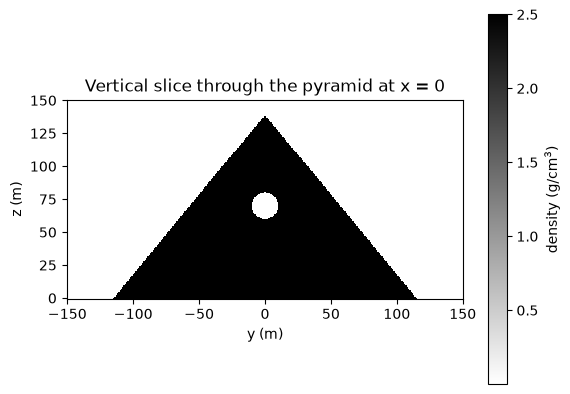

In [3]:
# YOUR TURN
y_vals = np.linspace(-150, 150, 300)
z_vals = np.linspace(0, 150, 200)
Y, Z = np.meshgrid(y_vals, z_vals, indexing='xy')

rho = np.zeros_like(Y)
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        rho[i, j] = target.density_at(0.0, Y[i, j], Z[i, j])

plt.pcolormesh(Y, Z, rho, shading='auto', cmap='gray_r')
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.title('Vertical slice through the pyramid at x = 0')
plt.colorbar(label=r'density (g/cm$^3$)')
plt.gca().set_aspect('equal')
plt.savefig('../figures/05_density_slice.png', dpi=300, bbox_inches='tight')
plt.show()

## Where does the detector go?

The baseline detector position is `(0, -40, 3)` m. The direction functions use two pointing angles, `ax` and `ay`; together they define the viewing direction.


In [4]:
detector = np.array(cfg.DETECTOR_POSITION_M, dtype=float)
d = mg.direction_from_angles(0.0, 0.0)
print('straight up:', d, '-> zenith', np.degrees(mg.zenith_from_direction(d)), 'deg')


straight up: [0. 0. 1.] -> zenith 0.0 deg


## Ray marching — supplied physics

`mg.trace_one_ray` is the supplied single-ray function. Read it before using it. It walks along a ray in 0.25 m steps and accumulates density × path length.


In [5]:
for deg in [0, 10, 20, 25, 30, 35, 40]:
    d = mg.direction_from_angles(0.0, np.radians(deg))
    X = mg.trace_one_ray(target, detector, d, step=cfg.RAY_STEP_M)
    print(f'ay = {deg:3d} deg   opacity = {X:9.0f} g/cm^2   ({X/100/2.5:6.1f} m of limestone)')


ay =   0 deg   opacity =     21999 g/cm^2   (  88.0 m of limestone)
ay =  10 deg   opacity =     28371 g/cm^2   ( 113.5 m of limestone)
ay =  20 deg   opacity =     34118 g/cm^2   ( 136.5 m of limestone)
ay =  25 deg   opacity =     29620 g/cm^2   ( 118.5 m of limestone)
ay =  30 deg   opacity =     26497 g/cm^2   ( 106.0 m of limestone)
ay =  35 deg   opacity =     26434 g/cm^2   ( 105.7 m of limestone)
ay =  40 deg   opacity =     29933 g/cm^2   ( 119.7 m of limestone)


### YOUR TURN — find the void by hand

Scan `ay` from 15° to 45° in 1° steps. Plot the opacity for the target and for `target.without_void()`. The chamber should create a notch that is absent in the no-void control.


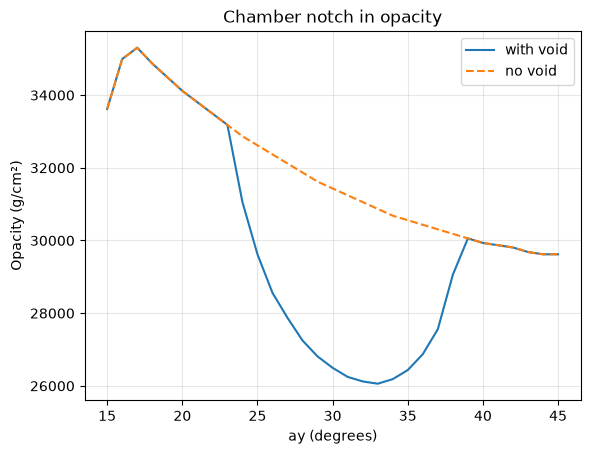

In [6]:
# YOUR TURN
angles = np.arange(15, 46, 1)
opacity_void = []
opacity_solid = []
for deg in angles:
    d = mg.direction_from_angles(0.0, np.radians(deg))
    opacity_void.append(mg.trace_one_ray(target, detector, d, step=cfg.RAY_STEP_M))
    opacity_solid.append(mg.trace_one_ray(target.without_void(), detector, d, step=cfg.RAY_STEP_M))

plt.plot(angles, opacity_void, label='with void')
plt.plot(angles, opacity_solid, '--', label='no void')
plt.xlabel('ay (degrees)')
plt.ylabel('Opacity (g/cm²)')
plt.title('Chamber notch in opacity')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../figures/06_opacity_notch.png', dpi=300, bbox_inches='tight')
plt.show()

## Making a whole image

### YOUR TURN — implement the shared function

Open `code/student_analysis.py` and implement:

```python
opacity_map(target, detector, field_deg=40, step_deg=2)
```

It should build `ax` and `ay` grids, trace one ray per direction using `mg.direction_from_angles` and `mg.trace_one_ray`, and return `(opacity, ax_deg, ay_deg)`. Keep the angle grids in degrees for plotting.

**Important:** this function lives in `student_analysis.py`, not only in this notebook. That makes notebooks 03–05 reproducible from a fresh kernel.


In [ ]:
# After implementing the function in code/student_analysis.py, run this cell.
opacity, ax_deg, ay_deg = sa.opacity_map(target, detector)
print('shape:', opacity.shape)


### YOUR TURN — display and validate

Display the opacity map with `origin='lower'`. Then repeat it for `target.without_void()`. Finally, repeat the map with `ray_step=0.125` m and compare it with the 0.25 m result. The change should be small.


In [ ]:
# YOUR TURN
